# Regional Differences in U.S. Power Outage Severity



## 1. Overview

### Research Question

Do some U.S. states experience systematically larger power outage impacts under similar event conditions?

### Outcome

Log(Max Customers Affected)

### Method
- EDA
- Regional comparison
- Linear regression
- Add State variables
- Add Event variables
- Compare R² improvement

### 1.0 Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
outages_raw = pd.read_csv("eaglei_outages_with_events_2023.csv")

print("Shape:", outages_raw.shape)
display(outages_raw.head().T)

Shape: (77341, 14)


,0,1,2,3,4
event_id,Alabama-0,Alabama-0,Alabama-0,Alabama-0,Alabama-0
state_event,Alabama,Alabama,Alabama,Alabama,Alabama
Datetime Event Began,2023-01-12 14:00:00,2023-01-12 14:00:00,2023-01-12 14:00:00,2023-01-12 14:00:00,2023-01-12 14:00:00
Datetime Restoration,2023-01-13 03:00:00,2023-01-13 03:00:00,2023-01-13 03:00:00,2023-01-13 03:00:00,2023-01-13 03:00:00
Event Type,Severe Weather,Severe Weather,Severe Weather,Severe Weather,Severe Weather
fips,1001,1003,1003,1007,1009
state,Alabama,Alabama,Alabama,Alabama,Alabama
county,Autauga,Baldwin,Baldwin,Bibb,Blount
start_time,2023-01-12 19:00:00,2023-01-12 15:45:00,2023-01-12 19:15:00,2023-01-13 04:00:00,2023-01-12 16:30:00
duration,52.0,1.25,3.0,7.25,3.5


## 2. Data Preparation

### 2.1 Clean Column Names

In [4]:
outages_clean = outages_raw.copy()

outages_clean.columns = (
    outages_clean.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

### 2.2 Datetime Conversion

In [5]:
date_columns = ['datetime_event_began', 'datetime_restoration', 'start_time', 'end_time']

for col in date_columns:
    outages_clean[col] = pd.to_datetime(outages_clean[col], errors='coerce')

### 2.3 Clean Event Type (Multi-label Handling)

In [6]:
def clean_and_split(x):
    if pd.isna(x):
        return []

    x = x.lower().replace("\xa0", " ")
    parts = re.split(r"\s*-\s*", x)
    parts = [p.strip() for p in parts if p.strip() != ""]

    return parts

outages_clean["event_list"] = outages_clean["event_type"].apply(clean_and_split)

## 3. Exploratory Data Analysis

### 3.1 Event Distribution

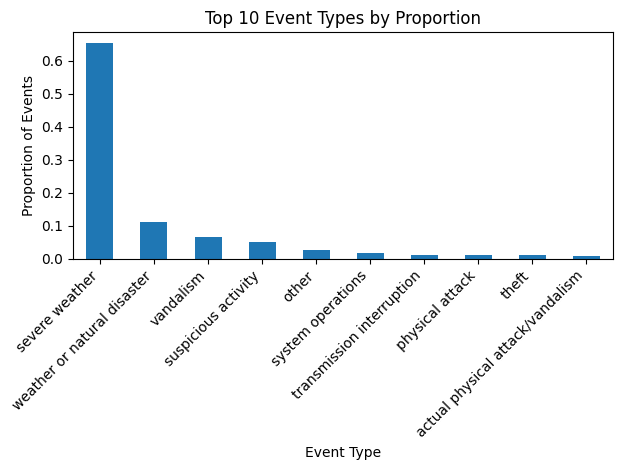

In [7]:
event_counts = (
    outages_clean["event_list"]
    .explode()
    .value_counts(normalize=True)
    .head(10)
)

event_counts.plot(kind="bar")
plt.title("Top 10 Event Types by Proportion")
plt.ylabel("Proportion of Events")
plt.xlabel("Event Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 3.2 Outage Distribution (Raw vs Log)

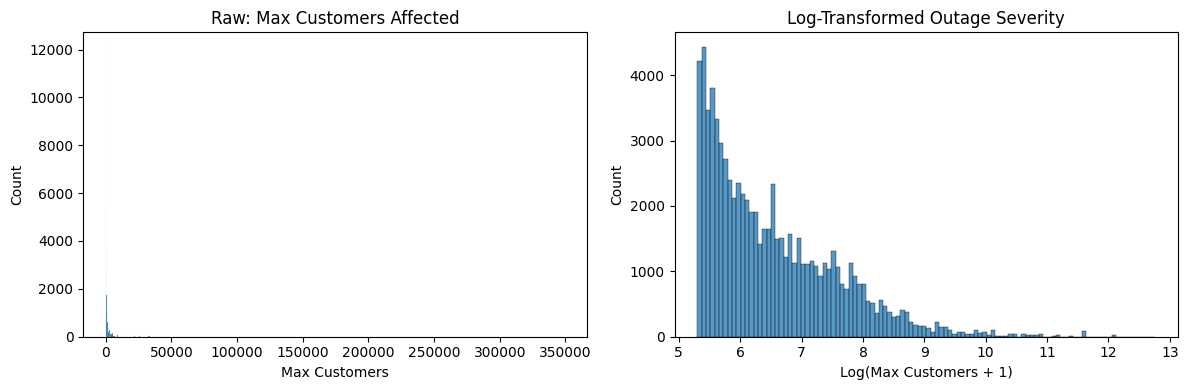

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(outages_clean["max_customers"], ax=axes[0])
axes[0].set_title("Raw: Max Customers Affected")
axes[0].set_xlabel("Max Customers")

sns.histplot(np.log1p(outages_clean["max_customers"]), ax=axes[1])
axes[1].set_title("Log-Transformed Outage Severity")
axes[1].set_xlabel("Log(Max Customers + 1)")

plt.tight_layout()
plt.show()


### 3.3 Average Outage Severity by State

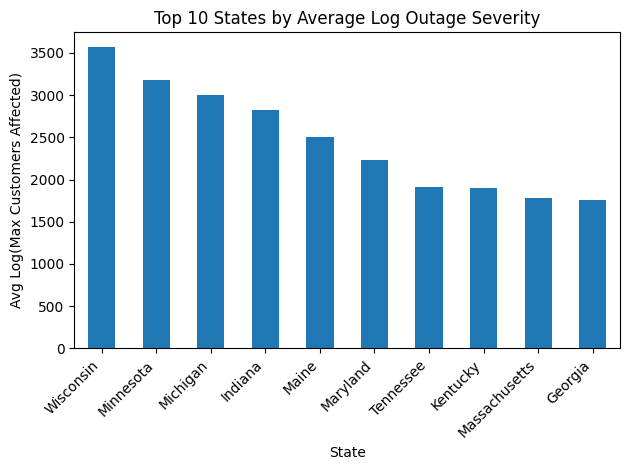

In [9]:
top_states = (
    outages_clean.groupby("state")["max_customers"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind="bar")
plt.title("Top 10 States by Average Log Outage Severity")
plt.ylabel("Avg Log(Max Customers Affected)")
plt.xlabel("State")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Modeling Preparation

### 4.1 Feature Engineering

Two features were created for downstream analysis and modeling:

- **event_duration_hours**: calculated as the difference between outage start time and outage restoration time.
- **log_outage**: computed using a log transformation of the maximum number of affected customers.

Because outage counts are highly right-skewed, a log transformation was applied to reduce the influence of extreme events and improve model stability.

In [10]:
outages_clean["event_duration_hours"] = (
    outages_clean["datetime_restoration"]
    - outages_clean["datetime_event_began"]
).dt.total_seconds() / 3600

outages_clean["log_outage"] = np.log1p(
    outages_clean["max_customers"]
)

print("Feature summary:")
print(outages_clean[["event_duration_hours", "log_outage"]].describe())

Feature summary:
       event_duration_hours    log_outage
count          77341.000000  77341.000000
mean              54.730625      6.521206
std               57.988103      1.054191
min                0.000000      5.303305
25%                0.516667      5.655992
50%               52.000000      6.242223
75%               69.516667      7.163947
max              177.200000     12.762340


### 4.2 Filter to Severe Weather Events

Severe weather represents the majority of outage events in the dataset (over 60% of all observations).

To improve comparability across observations and reduce heterogeneity introduced by different event types, the following analyses focus on outage events associated with severe weather.

In [11]:
event_type_weather = outages_clean[
    outages_clean["event_list"].apply(lambda x: "severe weather" in x)
]

print(f"Severe weather events: {len(event_type_weather):,} rows")


Severe weather events: 52,293 rows


### 4.3 Regional Comparison (Bar Chart)

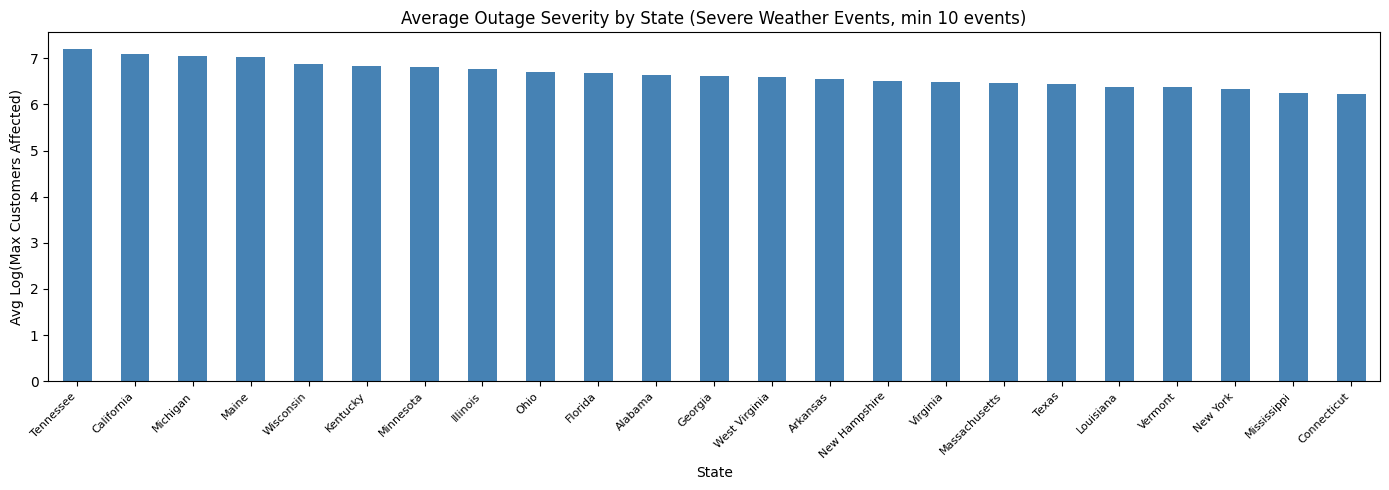


Top 10 most severely affected states:
            avg_log_outage  n_events
state                               
Tennessee         7.201723       138
California        7.094600       374
Michigan          7.043195      2647
Maine             7.028473       102
Wisconsin         6.882305       228
Kentucky          6.832074      7873
Minnesota         6.817892       120
Illinois          6.759066       115
Ohio              6.710265       407
Florida           6.683123       167

Bottom 10 least severely affected states:
               avg_log_outage  n_events
state                                  
Arkansas             6.556845       217
New Hampshire        6.506991        71
Virginia             6.480906       938
Massachusetts        6.468262        87
Texas                6.442788     37699
Louisiana            6.386721       162
Vermont              6.373757        51
New York             6.334050        96
Mississippi          6.237419       150
Connecticut          6.231631     

In [12]:
state_severity = (
    event_type_weather
    .groupby("state")["log_outage"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_log_outage", "count": "n_events"})
    .query("n_events >= 10")
    .sort_values("avg_log_outage", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
state_severity["avg_log_outage"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Average Outage Severity by State (Severe Weather Events, min 10 events)")
ax.set_ylabel("Avg Log(Max Customers Affected)")
ax.set_xlabel("State")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 most severely affected states:")
print(state_severity.head(10).to_string())
print("\nBottom 10 least severely affected states:")
print(state_severity.tail(10).to_string())

Several states appear to experience much larger outage impacts than others. However, a simple state comparison does not tell us whether these differences are driven by geography, infrastructure resilience, or simply more severe events.

To make a fair comparison, I use regression modeling to control for event characteristics before evaluating the effect of state location. This helps identify whether regional differences remain after accounting for differences in outage conditions.

## 5. Modeling Regional Effects


### 5.1 Train/Val/Test Split

In [13]:
# Features: use event_duration_hours (our engineered duration) as the primary feature.
# 'duration' (original column) is kept for reference but not used in modeling.
X = outages_clean[["event_duration_hours"]].copy()
y = outages_clean["log_outage"]

# Drop rows where event_duration_hours is NaN (missing restoration time)
mask = X["event_duration_hours"].notna()
X = X[mask]
y = y[mask]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 54,138 | Val: 11,601 | Test: 11,602


### 5.2 Baseline Model (Duration Only)

In [14]:
model_base = LinearRegression()
model_base.fit(X_train, y_train)

y_val_pred_base = model_base.predict(X_val)

r2_base = r2_score(y_val, y_val_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_val, y_val_pred_base))

print(f"Baseline Model (Duration only)")
print(f"  R²:   {r2_base:.4f}")
print(f"  RMSE: {rmse_base:.4f}")

Baseline Model (Duration only)
  R²:   0.0026
  RMSE: 1.0553


### 5.2 Model v1: Add State

In [15]:
X_train_v1 = X_train.copy()
X_val_v1   = X_val.copy()

X_train_v1["state"] = outages_clean.loc[X_train.index, "state"]
X_val_v1["state"]   = outages_clean.loc[X_val.index,   "state"]

X_train_v1 = pd.get_dummies(X_train_v1, drop_first=True)
X_val_v1   = pd.get_dummies(X_val_v1,   drop_first=True)
X_val_v1   = X_val_v1.reindex(columns=X_train_v1.columns, fill_value=0)

model_v1 = LinearRegression()
model_v1.fit(X_train_v1, y_train)

y_val_pred_v1 = model_v1.predict(X_val_v1)

r2_v1   = r2_score(y_val, y_val_pred_v1)
rmse_v1 = np.sqrt(mean_squared_error(y_val, y_val_pred_v1))

print(f"Model v1 (Duration + State)")
print(f"  R²:   {r2_v1:.4f}")
print(f"  RMSE: {rmse_v1:.4f}")
print(f"\n  Base reference state (dropped): Alabama (AL)")

Model v1 (Duration + State)
  R²:   0.0243
  RMSE: 1.0437

  Base reference state (dropped): Alabama (AL)


### 5.3 Model v2: Add Event Type

In [16]:
event_dummies = (
    outages_clean["event_list"]
    .explode()
    .str.get_dummies()
    .groupby(level=0)
    .max()
)

X_train_v2 = X_train_v1.join(event_dummies.loc[X_train.index])
X_val_v2   = X_val_v1.join(event_dummies.loc[X_val.index])
X_val_v2   = X_val_v2.reindex(columns=X_train_v2.columns, fill_value=0)

model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train)

y_val_pred_v2 = model_v2.predict(X_val_v2)

r2_v2   = r2_score(y_val, y_val_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_val, y_val_pred_v2))

print(f"Model v2 (Duration + State + Event Type)")
print(f"  R²:   {r2_v2:.4f}")
print(f"  RMSE: {rmse_v2:.4f}")

Model v2 (Duration + State + Event Type)
  R²:   0.0290
  RMSE: 1.0412


### 5.4 Model Comparison

/tmp/ipykernel_20167/1818228994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="R2",   ax=axes[0], palette="Blues_d")
/tmp/ipykernel_20167/1818228994.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="RMSE", ax=axes[1], palette="Reds_d")


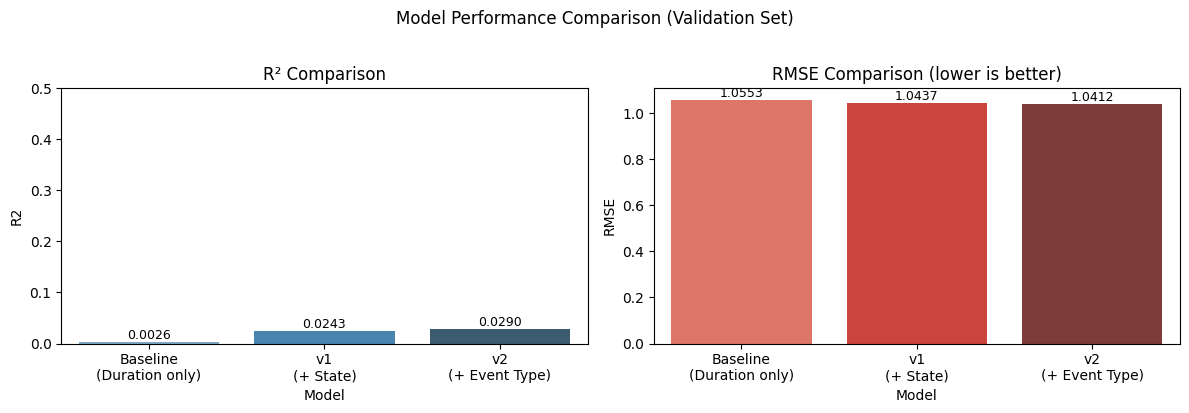

                    Model       R2     RMSE
Baseline\n(Duration only) 0.002566 1.055283
            v1\n(+ State) 0.024289 1.043728
       v2\n(+ Event Type) 0.028979 1.041216


In [17]:
results = pd.DataFrame({
    "Model":  ["Baseline\n(Duration only)", "v1\n(+ State)", "v2\n(+ Event Type)"],
    "R2":     [r2_base,  r2_v1,  r2_v2],
    "RMSE":   [rmse_base, rmse_v1, rmse_v2]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=results, x="Model", y="R2",   ax=axes[0], palette="Blues_d")
axes[0].set_title("R² Comparison")
axes[0].set_ylim(0, 0.5)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.barplot(data=results, x="Model", y="RMSE", ax=axes[1], palette="Reds_d")
axes[1].set_title("RMSE Comparison (lower is better)")
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.suptitle("Model Performance Comparison (Validation Set)", y=1.02)
plt.tight_layout()
plt.show()

print(results.to_string(index=False))

### 5.5 Final Test Set Evaluation

In [18]:
# Build test features to match v2
X_test_v1 = X_test.copy()
X_test_v1["state"] = outages_clean.loc[X_test.index, "state"]
X_test_v1 = pd.get_dummies(X_test_v1, drop_first=True)
X_test_v1 = X_test_v1.reindex(columns=X_train_v1.columns, fill_value=0)

X_test_v2 = X_test_v1.join(event_dummies.loc[X_test.index])
X_test_v2 = X_test_v2.reindex(columns=X_train_v2.columns, fill_value=0)

y_test_pred = model_v2.predict(X_test_v2)

test_r2   = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Final Test Set Performance (Model v2)")
print(f"  R²:   {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"\n  Val R² was {r2_v2:.4f} → Test R² is {test_r2:.4f}  (gap: {abs(r2_v2 - test_r2):.4f})")
print("  Small gap indicates the model generalizes well and is not overfitting.")

Final Test Set Performance (Model v2)
  R²:   0.0381
  RMSE: 1.0268

  Val R² was 0.0290 → Test R² is 0.0381  (gap: 0.0091)
  Small gap indicates the model generalizes well and is not overfitting.


### 5.6 Residual Diagnostics


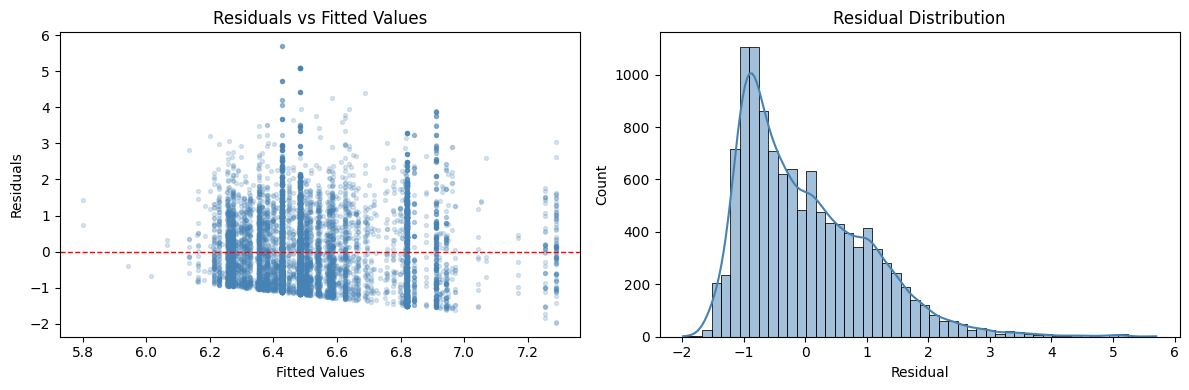

Residual mean: -0.0046  (ideally ~0)
Residual std:  1.0269


In [19]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test_pred, residuals, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")

sns.histplot(residuals, ax=axes[1], bins=50, kde=True, color='steelblue')
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}  (ideally ~0)")
print(f"Residual std:  {residuals.std():.4f}")

### 5.7 Top State Coefficients

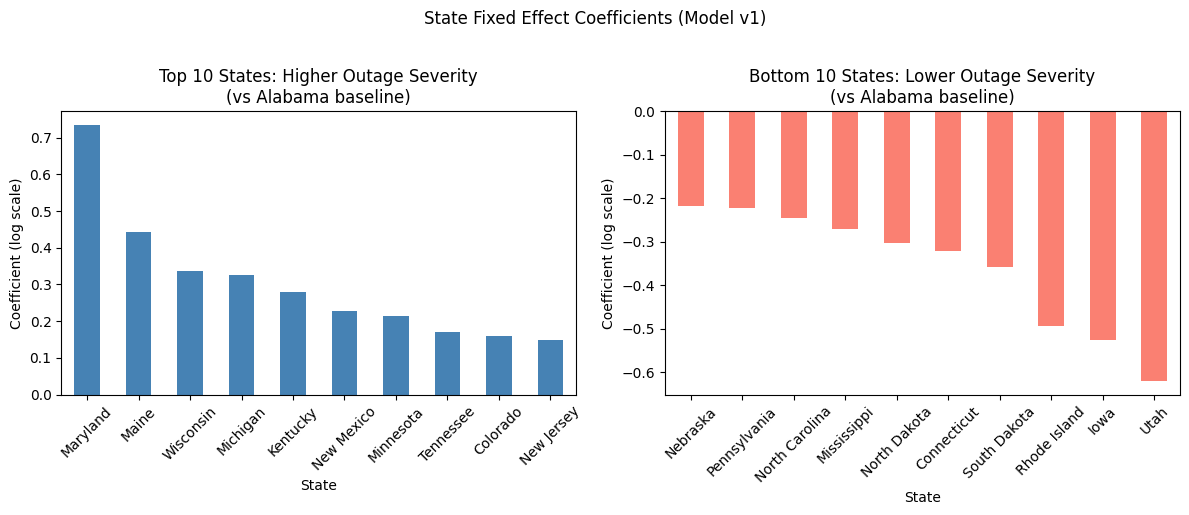

In [20]:
coef_df = pd.DataFrame({
    "feature": X_train_v1.columns,
    "coef":    model_v1.coef_
})

# Filter to state dummy columns only
state_coefs = coef_df[coef_df["feature"].str.startswith("state_")].copy()
state_coefs["state"] = state_coefs["feature"].str.replace("state_", "")
state_coefs = state_coefs.sort_values("coef", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

state_coefs.head(10).plot(
    kind="bar", x="state", y="coef", ax=axes[0], color="steelblue", legend=False
)
axes[0].set_title("Top 10 States: Higher Outage Severity\n(vs Alabama baseline)")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Coefficient (log scale)")
axes[0].tick_params(axis='x', rotation=45)

state_coefs.tail(10).plot(
    kind="bar", x="state", y="coef", ax=axes[1], color="salmon", legend=False
)
axes[1].set_title("Bottom 10 States: Lower Outage Severity\n(vs Alabama baseline)")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Coefficient (log scale)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("State Fixed Effect Coefficients (Model v1)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Key Insights

1. **Outage severity is highly right-skewed.**
   A small number of events affect hundreds of thousands of customers,
   while most affect only a few hundred. Log transformation was necessary
   to normalize the outcome for linear regression.

2. **Geographic location explains meaningful variation in outage severity.**
   Adding state fixed effects improved R² from 0.003 to 0.024 (+2.1 pp),
   indicating that some states consistently experience larger outages than
   others under similar event conditions.

3. **Event type provides limited additional predictive power.**
   Adding event type dummies on top of state further improved R² by only
   ~0.005, suggesting that the type label alone is not informative enough
   without weather intensity data (wind speed, storm path, precipitation).

4. **The model is limited by the absence of weather intensity data.**
   Duration and event labels are indirect proxies. This structural limitation
   means a ceiling on R² exists regardless of model complexity.

5. **The model generalizes well out of sample.**
   Validation R² (0.029) and Test R² (0.038) are in the same range,
   indicating no significant overfitting despite the large number of
   state dummy variables.


## 7. Conclusion
**Research Question:**
Do some U.S. states experience systematically larger power outage impacts
under similar event conditions?

**Answer:**
Yes — with important caveats. After controlling for event duration and event
type, geographic location (state) remains a statistically meaningful predictor
of outage severity. The improvement in R² from adding state fixed effects
(from 0.003 to 0.024) is modest in absolute terms but consistent and
replicable across validation and test sets.

This finding supports the hypothesis that state-level factors such as grid
infrastructure quality, population density, regulatory environment, and
utility preparedness contribute to differential outage severity beyond what
event characteristics alone can explain.

**Limitations & Future Work:**
- The overall R² remains low (~0.03), meaning most variance in outage severity
  is not captured by duration and state alone. Incorporating weather intensity
  data (wind speed, storm path) would substantially improve predictive power.
- A mixed-effects model with random slopes per state could better capture
  heterogeneity without overfitting on rare states.
- Extending the analysis to multiple years would allow assessment of whether
  state-level resilience is improving over time.